# 2026_JAN_14_CNSL_DATA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# File paths
score_file = "/home/hungdx/code/Lightning-hydra/logs/results/CNSL_Q1_2026_benchmarks/XLSR_ConformerTCM_MDT_RawboostLA_DF/2026_JAN_14_CNSL_DATA_cnsl_lora_elevenlabs_xlsr_conformertcm_mdt_lora_infer_XLSR_ConformerTCM_MDT_RawboostLA_DF.txt"
eval_parquet_path = "/home/hungdx/code/Lightning-hydra/data/DVC_DSD-Large-Corpus/metadata/2026_JAN_14_23H_09M_DSD_corpus_eval.parquet"

# Parse score file (handle paths with spaces by reading from the end)
def parse_score_file(filepath):
    data = []
    with open(filepath, 'r') as f:
        for line in f:
            parts = line.strip().rsplit(' ', 2)  # Split from right, max 2 splits
            if len(parts) == 3:
                path, spoof_score, bonafide_score = parts
                data.append({
                    'path': path,
                    'spoof_score': float(spoof_score),
                    'bonafide_score': float(bonafide_score)
                })
    return pd.DataFrame(data)

score_df = parse_score_file(score_file)
eval_df = pd.read_parquet(eval_parquet_path)

print(f"Score file: {len(score_df)} entries")
print(f"Eval parquet: {len(eval_df)} entries")
score_df.head()

Score file: 117426 entries
Eval parquet: 65762 entries


,path,spoof_score,bonafide_score
0,202410_Elevenlabs/Synthesizers/202410_Elevenla...,5.892756,-6.022877
1,202410_Elevenlabs/Synthesizers/202410_Elevenla...,6.119998,-6.263618
2,202410_Elevenlabs/Synthesizers/202410_Elevenla...,-1.008698,1.154964
3,202410_Elevenlabs/Synthesizers/202410_Elevenla...,5.849128,-5.978279
4,202410_Elevenlabs/Synthesizers/202410_Elevenla...,6.008684,-6.145645


In [2]:
# Merge score_df with eval_df on path
merged_df = score_df.merge(eval_df, on='path', how='inner')

# Calculate prediction: if bonafide_score > spoof_score -> predict bonafide
merged_df['pred_label'] = np.where(merged_df['bonafide_score'] > merged_df['spoof_score'], 'bonafide', 'spoof')

# Check if prediction is correct
merged_df['is_correct'] = merged_df['pred_label'] == merged_df['label']
merged_df['is_misclassified'] = ~merged_df['is_correct']

print(f"Merged samples: {len(merged_df)}")
print(f"Accuracy: {merged_df['is_correct'].mean()*100:.2f}%")
print(f"Misclassified: {merged_df['is_misclassified'].sum()} samples ({merged_df['is_misclassified'].mean()*100:.2f}%)")
merged_df.head()

Merged samples: 119744
Accuracy: 89.30%
Misclassified: 12811 samples (10.70%)


,path,spoof_score,bonafide_score,subset,label,utt_id,group,speaker_name,language,gender,...,noise_type_1,tts_or_vc,is_multi_speaker,source,joined_from_csv,join_key,dup_idx,pred_label,is_correct,is_misclassified
0,202410_Elevenlabs/Synthesizers/202410_Elevenla...,5.892756,-6.022877,eval,spoof,Synthesizers/202410_Elevenlabs/TTS_Adam_multi_...,202410_Elevenlabs,Adam,English,Male,...,-,TTS,No,dec2025,True,Synthesizers/202410_Elevenlabs/TTS_Adam_multi_...,0,spoof,True,False
1,202410_Elevenlabs/Synthesizers/202410_Elevenla...,6.119998,-6.263618,eval,spoof,Synthesizers/202410_Elevenlabs/TTS_Adam_multi_...,202410_Elevenlabs,Adam,English,Male,...,-,TTS,No,dec2025,True,Synthesizers/202410_Elevenlabs/TTS_Adam_multi_...,0,spoof,True,False
2,202410_Elevenlabs/Synthesizers/202410_Elevenla...,-1.008698,1.154964,dev,spoof,Synthesizers/202410_Elevenlabs/TTS_Adam_multi_...,202410_Elevenlabs,Adam,English,Male,...,-,TTS,No,dec2025,True,Synthesizers/202410_Elevenlabs/TTS_Adam_multi_...,0,bonafide,False,True
3,202410_Elevenlabs/Synthesizers/202410_Elevenla...,5.849128,-5.978279,eval,spoof,Synthesizers/202410_Elevenlabs/TTS_Adam_multi_...,202410_Elevenlabs,Adam,English,Male,...,-,TTS,No,dec2025,True,Synthesizers/202410_Elevenlabs/TTS_Adam_multi_...,0,spoof,True,False
4,202410_Elevenlabs/Synthesizers/202410_Elevenla...,6.008684,-6.145645,eval,spoof,Synthesizers/202410_Elevenlabs/TTS_Adam_multi_...,202410_Elevenlabs,Adam,English,Male,...,-,TTS,No,dec2025,True,Synthesizers/202410_Elevenlabs/TTS_Adam_multi_...,0,spoof,True,False


In [3]:
# Analyze misclassification by GROUP
group_stats = merged_df.groupby('group').agg(
    total=('is_correct', 'count'),
    correct=('is_correct', 'sum'),
    misclassified=('is_misclassified', 'sum'),
    accuracy=('is_correct', 'mean'),
    error_rate=('is_misclassified', 'mean')
).sort_values('error_rate', ascending=False)

group_stats['accuracy_pct'] = (group_stats['accuracy'] * 100).round(2)
group_stats['error_rate_pct'] = (group_stats['error_rate'] * 100).round(2)

print("=" * 80)
print("MISCLASSIFICATION BY GROUP (sorted by error rate)")
print("=" * 80)
group_stats[['total', 'misclassified', 'accuracy_pct', 'error_rate_pct']]

MISCLASSIFICATION BY GROUP (sorted by error rate)


,total,misclassified,accuracy_pct,error_rate_pct
group,,,,
Veo3,1000,290,71.00,29.00
Sora,1002,288,71.26,28.74
Elevenlabs,1006,220,78.13,21.87
VITS-TTS,812,168,79.31,20.69
2024_Telephone_Fake,98,20,79.59,20.41
AIHub Elevenlabs,1000,202,79.80,20.20
AIHub,690,138,80.00,20.00
MeloTTS,1000,200,80.00,20.00
Tortoise-TTS,1192,236,80.20,19.80


In [4]:
# Analyze misclassification by MODEL TYPE
model_stats = merged_df.groupby('model').agg(
    total=('is_correct', 'count'),
    correct=('is_correct', 'sum'),
    misclassified=('is_misclassified', 'sum'),
    accuracy=('is_correct', 'mean'),
    error_rate=('is_misclassified', 'mean')
).sort_values('error_rate', ascending=False)

model_stats['accuracy_pct'] = (model_stats['accuracy'] * 100).round(2)
model_stats['error_rate_pct'] = (model_stats['error_rate'] * 100).round(2)

print("=" * 80)
print("MISCLASSIFICATION BY MODEL TYPE (sorted by error rate)")
print("=" * 80)
model_stats[['total', 'misclassified', 'accuracy_pct', 'error_rate_pct']]

MISCLASSIFICATION BY MODEL TYPE (sorted by error rate)


,total,misclassified,accuracy_pct,error_rate_pct
model,,,,
a05,374,224,40.11,59.89
a11,250,130,48.00,52.00
a16,304,142,53.29,46.71
a08,544,228,58.09,41.91
a18,400,156,61.00,39.00
...,...,...,...,...
a06,302,0,100.00,0.00
a03,290,0,100.00,0.00
a19,370,0,100.00,0.00


In [5]:
# Analyze misclassification by GROUP + MODEL combination
group_model_stats = merged_df.groupby(['group', 'model']).agg(
    total=('is_correct', 'count'),
    misclassified=('is_misclassified', 'sum'),
    error_rate=('is_misclassified', 'mean')
).sort_values('error_rate', ascending=False)

group_model_stats['error_rate_pct'] = (group_model_stats['error_rate'] * 100).round(2)

# Filter to show only groups with significant misclassification (>5% error rate and >10 samples)
significant_errors = group_model_stats[
    (group_model_stats['error_rate'] > 0.05) & (group_model_stats['total'] > 10)
]

print("=" * 80)
print("TOP GROUP + MODEL COMBINATIONS WITH HIGH ERROR RATE (>5%, >10 samples)")
print("=" * 80)
significant_errors[['total', 'misclassified', 'error_rate_pct']].head(30)

TOP GROUP + MODEL COMBINATIONS WITH HIGH ERROR RATE (>5%, >10 samples)


total  misclassified  error_rate_pct
group                  model                                             
asvspoof2021_la_eval   A08              26             18           69.23
spoofceleb             a05             374            224           59.89
                       a11             250            130           52.00
asvspoof2021_la_eval   A11             328            156           47.56
spoofceleb             a16             304            142           46.71
asvspoof2021_la_eval   A16             344            146           42.44
spoofceleb             a08             544            228           41.91
                       a18             400            156           39.00
asvspoof2021_la_eval   A18             378            130           34.39
spoofceleb             a14             256             88           34.38
replaydf               xtts_v1.1      1258            378           30.05
Veo3                   Veo3_Dec25     1000            290           29.00
speechfake             CosyVoice      1014            294           28.99
asvspoof2021_la_eval   A14             380            110           28.95
ASVspoof2019_spoof     A19             180             52           28.89
Sora                   Sora_Dec25     1002            288           28.74
asvspoof5_release_eval AC2            1000            286           28.60
spoofceleb             a20            1000            286           28.60
                       a23            1000            286           28.60
speechfake             GPTSoVITS_VC   1114            316           28.37
tts_sasv_eval_anony    TTS_5            86             24           27.91
speechfake             OpenVoice      1064            296           27.82
asvspoof5_release_eval AC3            1000            266           26.60
ASVspoof5_spoof        A13             220             58           26.36
speechfake             SeedVC         1002            260           25.95
ASVspoof5_spoof        A10             204             48           23.53
tts_sasv_eval_anony    TTS_1            86             20           23.26
ASVspoof5_spoof        A06             308             70           22.73
spoofceleb             a22            1000            220           22.00
ASVspoof2019_spoof     A05             338             74           21.89

In [6]:
# Analyze by error type: False Positive vs False Negative
# False Positive: bonafide predicted as spoof
# False Negative: spoof predicted as bonafide (more dangerous!)

merged_df['error_type'] = np.where(
    merged_df['is_correct'], 'Correct',
    np.where(merged_df['label'] == 'bonafide', 'False Positive (bonafide→spoof)', 'False Negative (spoof→bonafide)')
)

error_type_stats = merged_df.groupby(['label', 'error_type']).size().unstack(fill_value=0)
print("=" * 80)
print("ERROR TYPE DISTRIBUTION")
print("=" * 80)
print(error_type_stats)
print()

# Calculate FP and FN rates
bonafide_df = merged_df[merged_df['label'] == 'bonafide']
spoof_df = merged_df[merged_df['label'] == 'spoof']

fp_rate = (bonafide_df['pred_label'] == 'spoof').mean() * 100
fn_rate = (spoof_df['pred_label'] == 'bonafide').mean() * 100

print(f"False Positive Rate (bonafide predicted as spoof): {fp_rate:.2f}%")
print(f"False Negative Rate (spoof predicted as bonafide): {fn_rate:.2f}%")

ERROR TYPE DISTRIBUTION
error_type  Correct  False Negative (spoof→bonafide)  \
label                                                  
bonafide      51101                                0   
spoof         55832                            11974   

error_type  False Positive (bonafide→spoof)  
label                                        
bonafide                                837  
spoof                                     0  

False Positive Rate (bonafide predicted as spoof): 1.61%
False Negative Rate (spoof predicted as bonafide): 17.66%


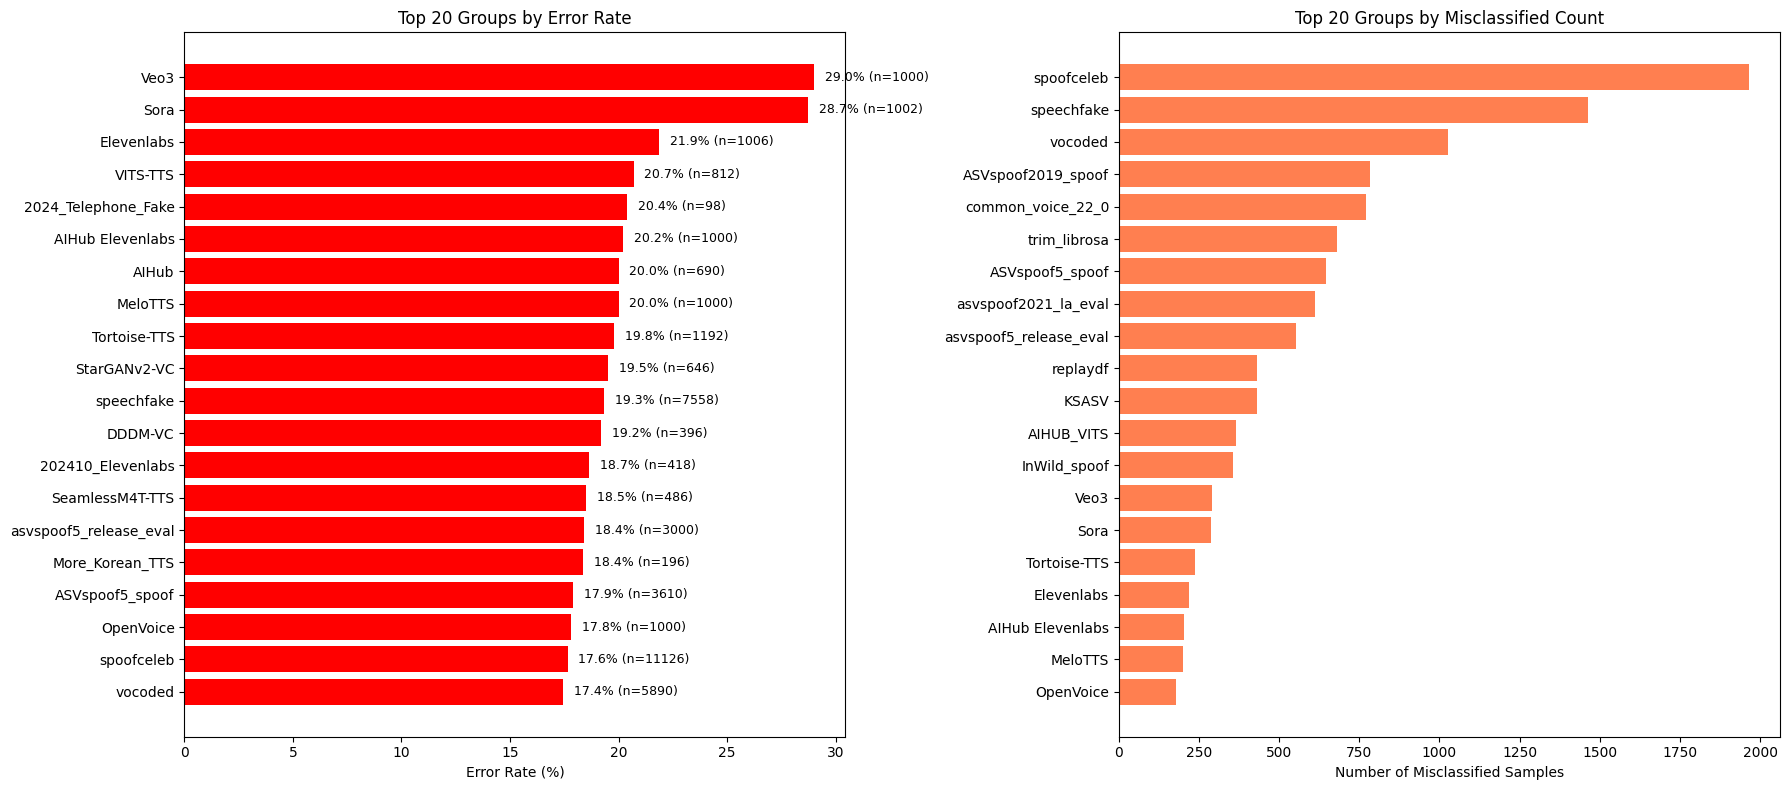

In [7]:
# Visualization 1: Misclassification by Group
plt.style.use('default')
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Plot 1: Error rate by group
top_groups = group_stats.head(20)
colors = ['red' if x > 10 else 'orange' if x > 5 else 'green' for x in top_groups['error_rate_pct']]
ax1 = axes[0]
bars = ax1.barh(range(len(top_groups)), top_groups['error_rate_pct'], color=colors)
ax1.set_yticks(range(len(top_groups)))
ax1.set_yticklabels(top_groups.index)
ax1.set_xlabel('Error Rate (%)')
ax1.set_title('Top 20 Groups by Error Rate')
ax1.invert_yaxis()

# Add value labels
for i, (v, total) in enumerate(zip(top_groups['error_rate_pct'], top_groups['total'])):
    ax1.text(v + 0.5, i, f'{v:.1f}% (n={total})', va='center', fontsize=9)

# Plot 2: Number of misclassified samples by group
top_misclassified = group_stats.sort_values('misclassified', ascending=False).head(20)
ax2 = axes[1]
ax2.barh(range(len(top_misclassified)), top_misclassified['misclassified'], color='coral')
ax2.set_yticks(range(len(top_misclassified)))
ax2.set_yticklabels(top_misclassified.index)
ax2.set_xlabel('Number of Misclassified Samples')
ax2.set_title('Top 20 Groups by Misclassified Count')
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig('misclassification_by_group.png', dpi=150, bbox_inches='tight')
plt.show()

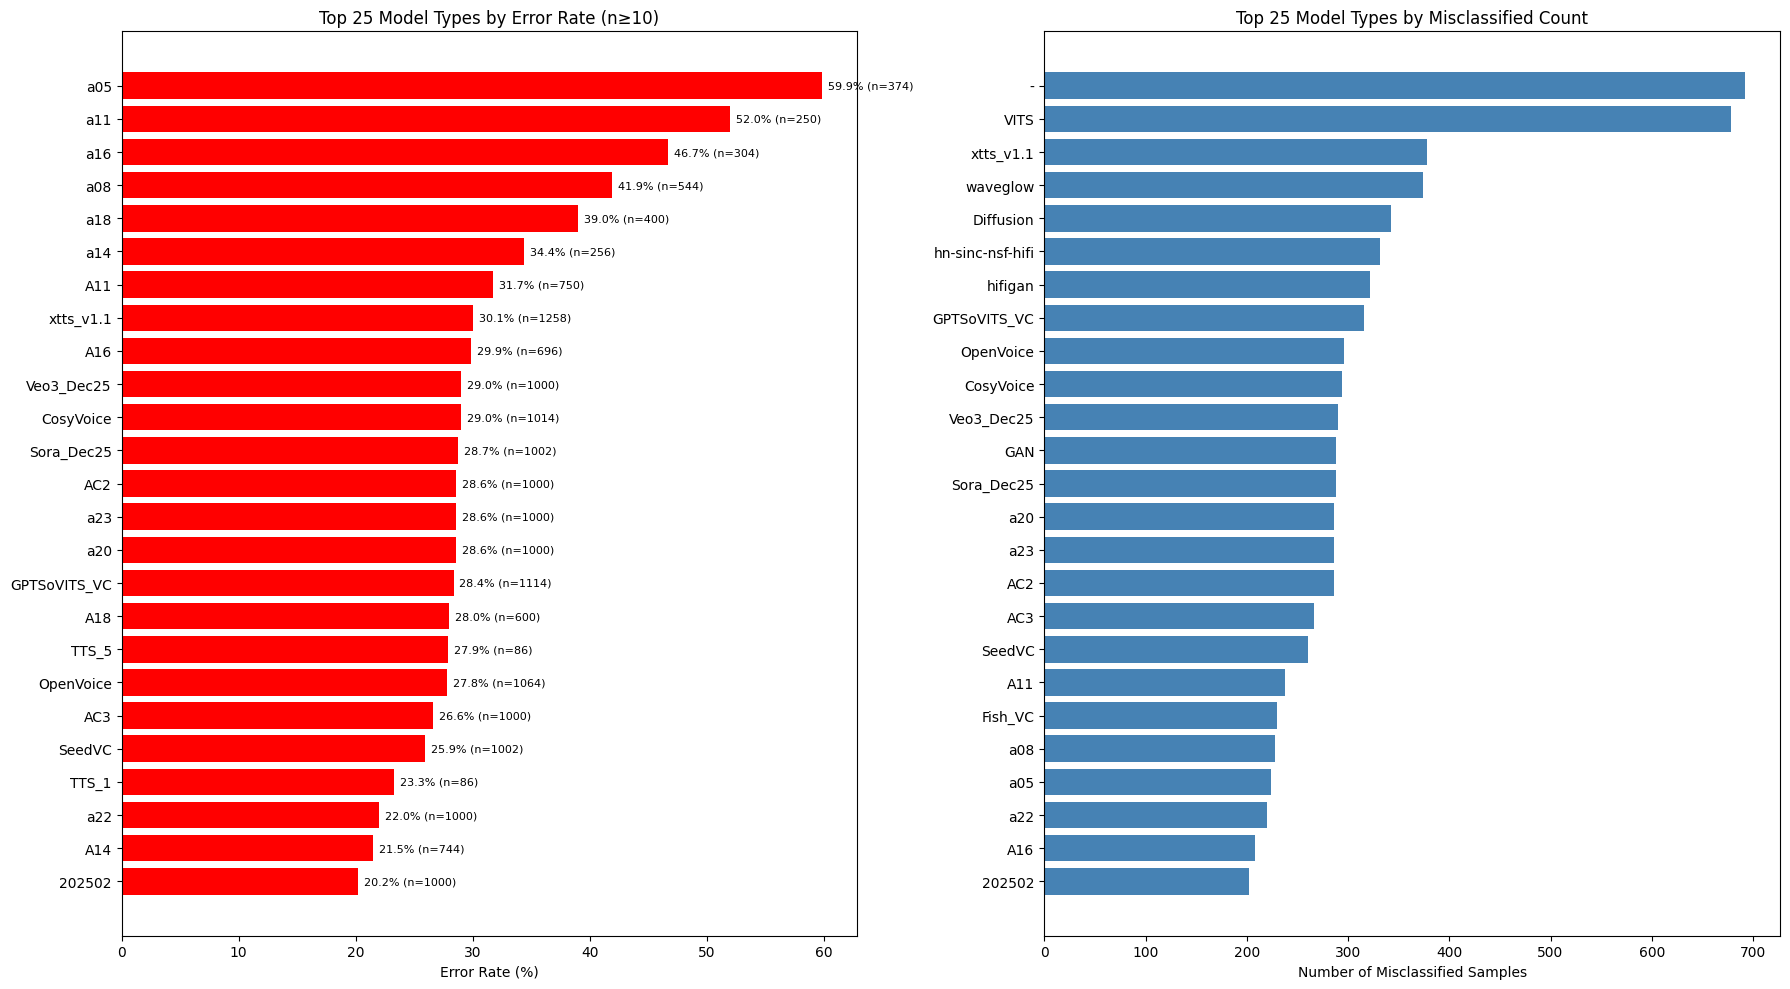

In [8]:
# Visualization 2: Misclassification by Model Type
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# Plot 1: Error rate by model (top 25)
top_models = model_stats[model_stats['total'] >= 10].head(25)  # At least 10 samples
colors = ['red' if x > 10 else 'orange' if x > 5 else 'green' for x in top_models['error_rate_pct']]
ax1 = axes[0]
ax1.barh(range(len(top_models)), top_models['error_rate_pct'], color=colors)
ax1.set_yticks(range(len(top_models)))
ax1.set_yticklabels([str(m)[:30] for m in top_models.index])  # Truncate long names
ax1.set_xlabel('Error Rate (%)')
ax1.set_title('Top 25 Model Types by Error Rate (n≥10)')
ax1.invert_yaxis()

for i, (v, total) in enumerate(zip(top_models['error_rate_pct'], top_models['total'])):
    ax1.text(v + 0.5, i, f'{v:.1f}% (n={total})', va='center', fontsize=8)

# Plot 2: Number of misclassified by model
top_model_misclassified = model_stats.sort_values('misclassified', ascending=False).head(25)
ax2 = axes[1]
ax2.barh(range(len(top_model_misclassified)), top_model_misclassified['misclassified'], color='steelblue')
ax2.set_yticks(range(len(top_model_misclassified)))
ax2.set_yticklabels([str(m)[:30] for m in top_model_misclassified.index])
ax2.set_xlabel('Number of Misclassified Samples')
ax2.set_title('Top 25 Model Types by Misclassified Count')
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig('misclassification_by_model.png', dpi=150, bbox_inches='tight')
plt.show()

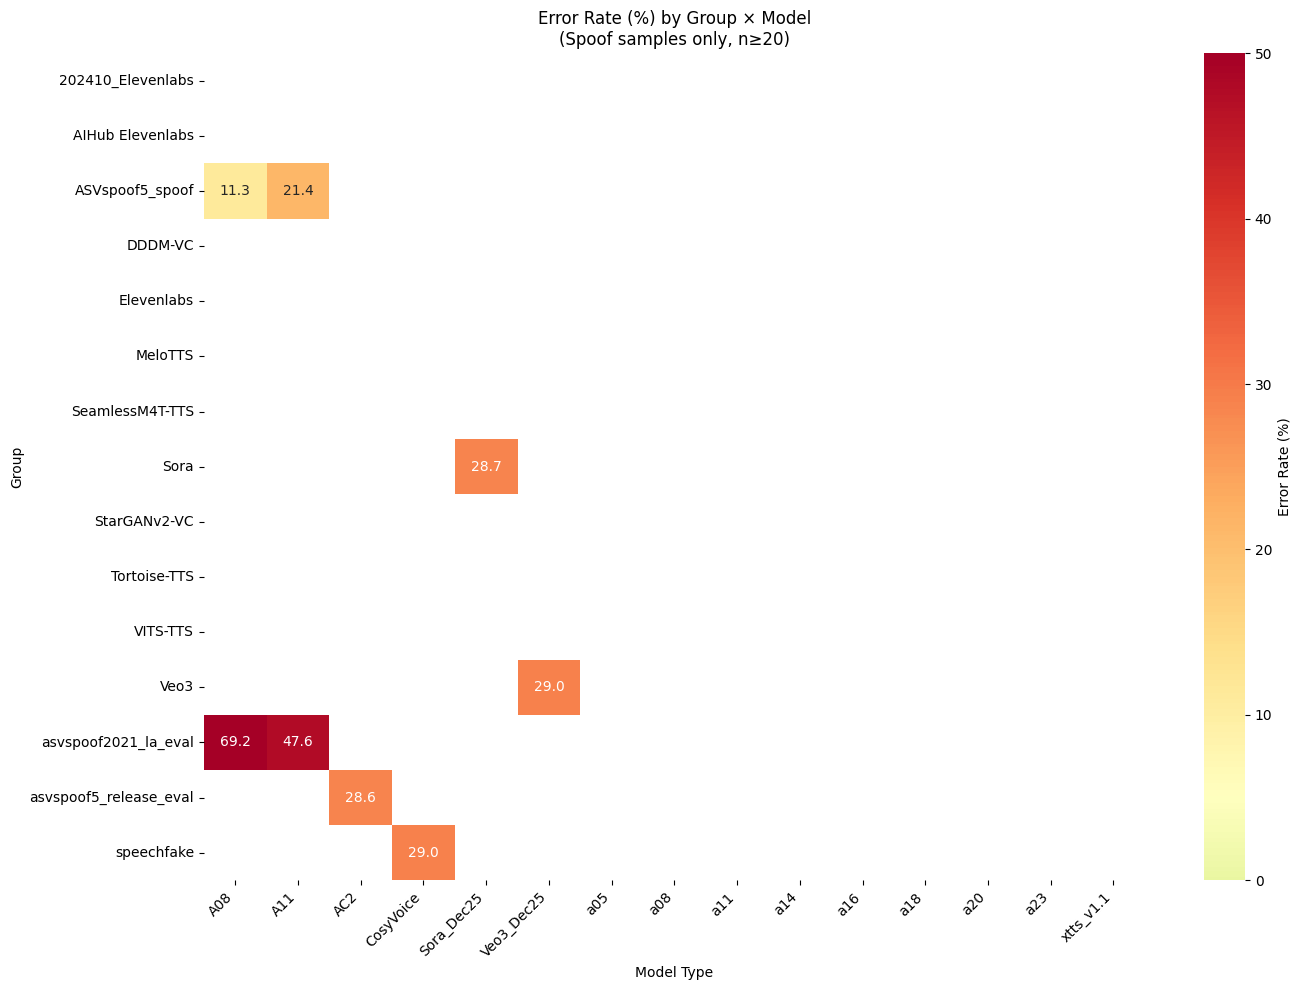

In [9]:
# Visualization 3: Heatmap of Error Rate by Group x Model (for groups with spoof samples)
# Filter spoof samples only (bonafide doesn't have model types)
spoof_only = merged_df[merged_df['label'] == 'spoof']

# Create pivot table for error rate
pivot_data = spoof_only.groupby(['group', 'model']).agg(
    error_rate=('is_misclassified', 'mean'),
    count=('is_misclassified', 'count')
).reset_index()

# Filter to significant combinations (>20 samples)
pivot_data = pivot_data[pivot_data['count'] >= 20]
pivot_error = pivot_data.pivot(index='group', columns='model', values='error_rate') * 100

# Select top groups and models by error rate
top_error_groups = pivot_data.groupby('group')['error_rate'].mean().nlargest(15).index
top_error_models = pivot_data.groupby('model')['error_rate'].mean().nlargest(15).index

pivot_filtered = pivot_error.loc[
    pivot_error.index.isin(top_error_groups),
    pivot_error.columns.isin(top_error_models)
]

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(pivot_filtered, annot=True, fmt='.1f', cmap='RdYlGn_r', 
            center=5, vmin=0, vmax=50, ax=ax,
            cbar_kws={'label': 'Error Rate (%)'})
ax.set_title('Error Rate (%) by Group × Model\n(Spoof samples only, n≥20)')
ax.set_xlabel('Model Type')
ax.set_ylabel('Group')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('heatmap_group_model_error.png', dpi=150, bbox_inches='tight')
plt.show()

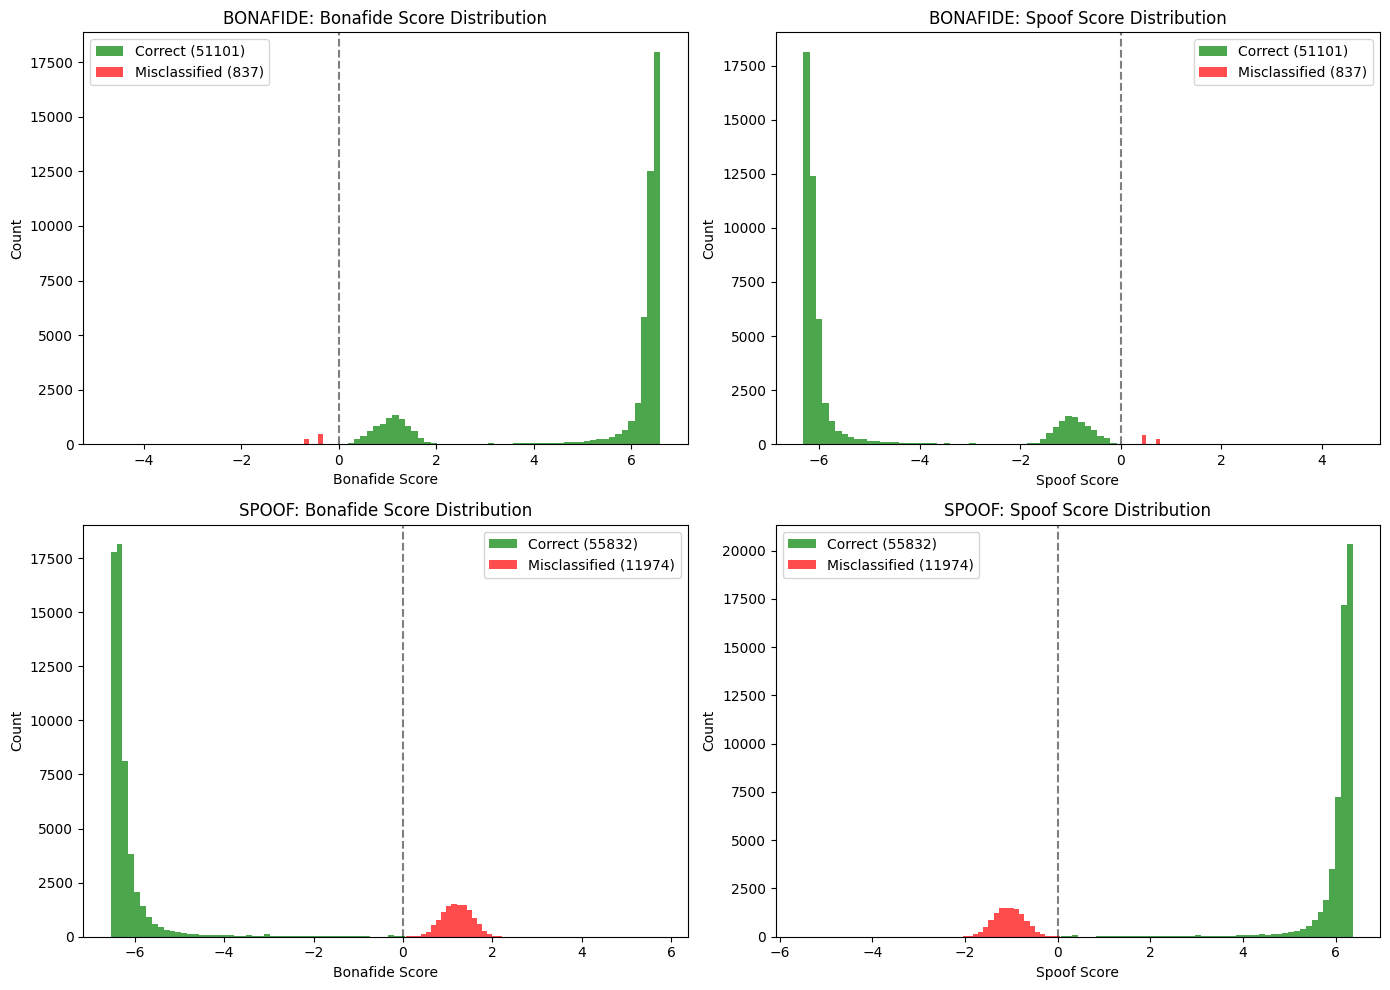

In [10]:
# Visualization 4: Score Distribution for Misclassified vs Correct
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot score distributions
for idx, label in enumerate(['bonafide', 'spoof']):
    subset = merged_df[merged_df['label'] == label]
    
    # Bonafide score distribution
    ax = axes[idx, 0]
    correct = subset[subset['is_correct']]['bonafide_score']
    wrong = subset[subset['is_misclassified']]['bonafide_score']
    ax.hist(correct, bins=50, alpha=0.7, label=f'Correct ({len(correct)})', color='green')
    ax.hist(wrong, bins=50, alpha=0.7, label=f'Misclassified ({len(wrong)})', color='red')
    ax.set_xlabel('Bonafide Score')
    ax.set_ylabel('Count')
    ax.set_title(f'{label.upper()}: Bonafide Score Distribution')
    ax.legend()
    ax.axvline(x=0, color='black', linestyle='--', alpha=0.5)
    
    # Spoof score distribution
    ax = axes[idx, 1]
    correct = subset[subset['is_correct']]['spoof_score']
    wrong = subset[subset['is_misclassified']]['spoof_score']
    ax.hist(correct, bins=50, alpha=0.7, label=f'Correct ({len(correct)})', color='green')
    ax.hist(wrong, bins=50, alpha=0.7, label=f'Misclassified ({len(wrong)})', color='red')
    ax.set_xlabel('Spoof Score')
    ax.set_ylabel('Count')
    ax.set_title(f'{label.upper()}: Spoof Score Distribution')
    ax.legend()
    ax.axvline(x=0, color='black', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# SUMMARY: Top Misclassified Combinations
print("=" * 100)
print("SUMMARY: WORST PERFORMING COMBINATIONS (sorted by number of misclassified samples)")
print("=" * 100)

# Get detailed misclassification by group + model + label
detailed_stats = merged_df.groupby(['group', 'model', 'label']).agg(
    total=('is_correct', 'count'),
    misclassified=('is_misclassified', 'sum'),
    error_rate=('is_misclassified', 'mean')
).reset_index()

detailed_stats['error_rate_pct'] = (detailed_stats['error_rate'] * 100).round(2)
detailed_stats = detailed_stats.sort_values('misclassified', ascending=False)

# Show top 30 worst combinations
print("\nTop 30 worst Group + Model + Label combinations:")
print(detailed_stats[['group', 'model', 'label', 'total', 'misclassified', 'error_rate_pct']].head(30).to_string(index=False))

# Additional analysis: by language and TTS/VC type
print("\n" + "=" * 100)
print("ANALYSIS BY LANGUAGE")
print("=" * 100)
lang_stats = merged_df.groupby('language').agg(
    total=('is_correct', 'count'),
    misclassified=('is_misclassified', 'sum'),
    error_rate=('is_misclassified', 'mean')
).sort_values('error_rate', ascending=False)
lang_stats['error_rate_pct'] = (lang_stats['error_rate'] * 100).round(2)
print(lang_stats[['total', 'misclassified', 'error_rate_pct']])

print("\n" + "=" * 100)
print("ANALYSIS BY TTS/VC TYPE")
print("=" * 100)
tts_vc_stats = merged_df.groupby('tts_or_vc').agg(
    total=('is_correct', 'count'),
    misclassified=('is_misclassified', 'sum'),
    error_rate=('is_misclassified', 'mean')
).sort_values('error_rate', ascending=False)
tts_vc_stats['error_rate_pct'] = (tts_vc_stats['error_rate'] * 100).round(2)
print(tts_vc_stats[['total', 'misclassified', 'error_rate_pct']])

SUMMARY: WORST PERFORMING COMBINATIONS (sorted by number of misclassified samples)

Top 30 worst Group + Model + Label combinations:
                 group            model label  total  misclassified  error_rate_pct
              replaydf        xtts_v1.1 spoof   1258            378           30.05
               vocoded         waveglow spoof   2084            374           17.95
            AIHUB_VITS             VITS spoof   2090            364           17.42
          InWild_spoof                - spoof   2290            356           15.55
               vocoded hn-sinc-nsf-hifi spoof   1916            332           17.33
               vocoded          hifigan spoof   1890            322           17.04
            speechfake     GPTSoVITS_VC spoof   1114            316           28.37
            speechfake        OpenVoice spoof   1064            296           27.82
            speechfake        CosyVoice spoof   1014            294           28.99
                  Veo3     

In [12]:
# Export misclassified samples for further analysis
misclassified_df = merged_df[merged_df['is_misclassified']].copy()
misclassified_df['score_diff'] = misclassified_df['bonafide_score'] - misclassified_df['spoof_score']

# Sort by confidence (how wrong the model was)
misclassified_df = misclassified_df.sort_values('score_diff', key=abs, ascending=False)

# Save to CSV
output_path = 'misclassified_samples.csv'
misclassified_df[['path', 'label', 'pred_label', 'spoof_score', 'bonafide_score', 'score_diff', 
                   'group', 'model', 'language', 'tts_or_vc', 'source']].to_csv(output_path, index=False)

print(f"Exported {len(misclassified_df)} misclassified samples to {output_path}")
print("\nMost confident wrong predictions (sorted by |score_diff|):")
misclassified_df[['path', 'label', 'pred_label', 'score_diff', 'group', 'model']].head(20)

Exported 12811 misclassified samples to misclassified_samples.csv

Most confident wrong predictions (sorted by |score_diff|):


,path,label,pred_label,score_diff,group,model
103596,Veo3/ITW_Spoof_Dec25_toys/Veo3/449/2.wav,spoof,bonafide,11.237809,Veo3,Veo3_Dec25
23505,Veo3/ITW_Spoof_Dec25_toys/Veo3/449/2.wav,spoof,bonafide,11.237809,Veo3,Veo3_Dec25
18624,MeloTTS/Synthesizers/MeloTTS/MeloTTS_621.wav,spoof,bonafide,10.932771,MeloTTS,VITS2
101703,MeloTTS/Synthesizers/MeloTTS/MeloTTS_621.wav,spoof,bonafide,10.932771,MeloTTS,VITS2
18613,MeloTTS/Synthesizers/MeloTTS/MeloTTS_605.wav,spoof,bonafide,10.086736,MeloTTS,VITS2
98423,MeloTTS/Synthesizers/MeloTTS/MeloTTS_605.wav,spoof,bonafide,10.086736,MeloTTS,VITS2
31941,common_voice_22_0/de/invalidated/de_invalidate...,bonafide,spoof,-9.293255,common_voice_22_0,None
108116,asvspoof2021_la_eval/LA_E_8401370.flac,spoof,bonafide,8.487366,asvspoof2021_la_eval,A16
25532,asvspoof2021_la_eval/LA_E_8401370.flac,spoof,bonafide,8.487366,asvspoof2021_la_eval,A16
38547,common_voice_22_0/ja/other/ja_other_5/common_v...,bonafide,spoof,-8.320879,common_voice_22_0,None
